# Turbulence spectra analysis

Load a developed forced-turbulence-3D run and do real spectral analysis on it:

1. developed-state check (energy vs time, choice of averaging window),
2. time-averaged perpendicular spectra with $k_\perp^{-5/3}$ / $k_\perp^{-3/2}$ references,
3. Elsasser ($z^\pm$) spectra,
4. residual energy spectrum $E_{res}(k_\perp) = E_u - E_b$,
5. parallel ($k_\parallel$) spectrum and spectral anisotropy,
6. a spectrum-vs-energy consistency check,
7. a real-space vorticity slice for context.

The forced-turbulence notebooks *run* simulations; this one demonstrates the *analysis*.
Part 0 below generates a dataset if you don't already have one; Part 1 is pure
post-processing, driven entirely by the snapshot directory.

In [1]:
import os
import jax
import jax.numpy as jnp
import jax.numpy.fft as ft
import numpy as np
import matplotlib.pyplot as plt

import taranis as jr
import taranis.snapshot_io as sn
import taranis.diagnostics as diag

# Point this at any developed forced-turbulence run's snapshot directory. If you already
# have one (e.g. from examples/forced-turbulence-3D.ipynb, or a run copied over from a
# cluster), set snap_path to it and Part 0 skips itself automatically.
snap_path = "data/turbulence-spectra-analysis/"

jax is using 32bit precision.


## Part 0 — data generation

**Skip this section if you already have a developed forced-turbulence-3D run** — point
`snap_path` above at it instead. The cell below skips itself whenever the directory
already contains a `params.json` *and* at least one saved snapshot.

Setup: $64^3$ forced RMHD in a $(2\pi)^3$ box, Elsasser-mode Ornstein–Uhlenbeck forcing
($z^+$ and $z^-$ driven independently, 0.15 injection power each = 0.3 total) in the large-scale shell
$1 \le |k_\perp| < 3$, hyperdissipation (`hyper=3`), quiescent (zero-field) start. We run
to $t_{end}=10$ with snapshots every $0.5$ — roughly 600–1000 adaptive steps
($dt \sim 0.01$–$0.02$ once turbulence is developed), a few minutes single-process.

`params.save(snap_path)` is called **before** the run: it records the constructor
arguments to `snap_path/params.json`, which is exactly what lets Part 1 (and any later
analysis session) reconstruct the run's `Parameters` from the directory alone via
`Parameters.from_snapshot`. Nothing writes `params.json` automatically — it's an explicit
call, and it makes the run directory self-documenting.

This is a single-process run. For a multi-rank generation run, move this cell's body into
a script and launch e.g. `mpirun -n 4 python generate.py` (requires the `[mpi]` extra and
`nz % size == 0`; with no MPI installed the backend auto-resolves to `"serial"`).
Note, though, that the parallel-spectrum section below (`diag.parspec`) needs the whole
z-domain on one rank — i.e. the single-process snapshot layout — so generate
single-process (or reshard on restore, see `docs/checkpointing.md`) if you want that
section to run.

In [2]:
if (not os.path.exists(os.path.join(snap_path, "params.json"))
        or len(sn.get_saved_steps(snap_path)) == 0):
    print("no existing run found -- generating one (a few minutes at 64^3)")

    params_gen = jr.Parameters(nx=64, ny=64, nz=64,
                               Lx=2.0*jnp.pi, Ly=2.0*jnp.pi, Lz=2.0*jnp.pi,
                               eqpars={'diss': (1e-5, 1e-5), 'hyper': 3},
                               cfl_safety=0.5, dims=3,
                               forcing=True, forcing_mode="elsasser",
                               forcing_power_elsasser=(0.15, 0.15),
                               forcing_tau=1.0, fshell=(1, 3), forcing_seed=42,
                               forcing_scale_max=1.0)
    params_gen.save(snap_path)  # BEFORE the run: the directory now documents itself

    mngr = jr.snapshot_manager_setup(params=params_gen, snap_path=snap_path, nsnap=100)
    kgrid_gen = jr.setup_kgrids(params_gen)

    def zero_init(x, y, z):
        # quiescent start: the forcing spins turbulence up from rest
        return jnp.zeros((2,) + jnp.broadcast_shapes(x.shape, y.shape, z.shape))

    state = jr.initialize(zero_init, params_gen)
    nblock = jr.estimate_good_nblock(state, kgrid_gen, params_gen,
                                     t_snap=0.5, t_end=10.0)
    # buffer donation: `state` is consumed by simulate_scan -- use only the return value
    end_state = jr.simulate_scan(state, kgrid_gen, params_gen, nblock,
                                 t_snap=0.5, t_end=10.0, mngr=mngr, save=True)
    del state, end_state, mngr, kgrid_gen, params_gen
else:
    print("found existing run, skipping generation -- using snapshots in " + snap_path)

found existing run, skipping generation -- using snapshots in data/turbulence-spectra-analysis/


## Part 1 — spectra analysis

Everything below is driven **only** by the snapshot directory:
`jr.Parameters.from_snapshot`, `sn.get_saved_steps`, `sn.load_snapshot`. It works
unchanged on *any* snapshot directory that carries a `params.json` — including one
`rsync`'d over from a cluster run (see `examples/postprocessing.ipynb` for that workflow,
including the `RMHD_PRECISION` caveat: set it to match the run *before* importing
`taranis`). No `Parameters` are constructed by hand in this part.

At $64^3$ each snapshot is only ~1 MB, so we cache them all in memory once.

In [3]:
params = jr.Parameters.from_snapshot(snap_path)
kgrid = jr.setup_kgrids(params)

steps = sn.get_saved_steps(snap_path)
print(f"{len(steps)} saved snapshots: {steps}")

snaps = {i: sn.load_snapshot(i, snap_path, params) for i in steps}
times = np.array([float(snaps[i].t) for i in steps])
print(f"t range: {times[0]:.3f} .. {times[-1]:.3f}")

21 saved snapshots: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


t range: 0.000 .. 10.001


### 1. Developed-state check: energy vs time

`diag.energy` returns $(E_{kin}, E_{mag}) = \tfrac12(\langle|\nabla_\perp\phi|^2\rangle,
\langle|\nabla_\perp\psi|^2\rangle)$, volume-averaged, on the same normalization
convention as `perpspec` and `forcing_power` (rfft2 ky-doubling, $/\,n_z (n_x n_y)^2$) —
so all the energy-like numbers in this notebook are directly comparable.

From a quiescent start the forcing first spins the system up (energy grows roughly
linearly at the injection rate), then dissipation catches up and the energies plateau
into a statistically steady state. We take the time-averaging window for all the spectra
below to be $t \ge 5$: as the plot shows, both $E_{kin}$ and $E_{mag}$ have plateaued by
then, so the window samples the steady state rather than the transient.

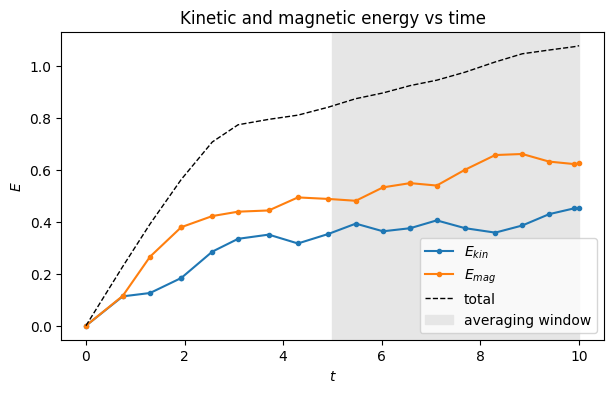

window t >= 5.0: 11 snapshots, <E_tot> = 0.9820 (std 0.0715)


In [4]:
E_kin = np.empty(len(steps))
E_mag = np.empty(len(steps))
for j, i in enumerate(steps):
    ek, em = diag.energy(snaps[i], kgrid, params)
    E_kin[j], E_mag[j] = float(ek), float(em)

t_avg_min = 5.0  # averaging window: energies have plateaued by t ~ 5

plt.figure(figsize=(7, 4))
plt.plot(times, E_kin, marker='o', ms=3, label=r'$E_{kin}$')
plt.plot(times, E_mag, marker='o', ms=3, label=r'$E_{mag}$')
plt.plot(times, E_kin + E_mag, 'k--', lw=1, label='total')
plt.axvspan(t_avg_min, times[-1], color='0.9', label='averaging window')
plt.xlabel(r'$t$')
plt.ylabel(r'$E$')
plt.legend()
plt.title('Kinetic and magnetic energy vs time')
plt.show()

win = times >= t_avg_min
print(f"window t >= {t_avg_min}: {win.sum()} snapshots, "
      f"<E_tot> = {(E_kin + E_mag)[win].mean():.4f} "
      f"(std {(E_kin + E_mag)[win].std():.4f})")

### 2. Time-averaged perpendicular spectra

`diag.perpspec` gives the z-averaged perpendicular energy spectra $E_u(k_\perp)$ (from
$\phi$) and $E_b(k_\perp)$ (from $\psi$), binned with `bin_factor=2` (bin width
$dk = 2 k_{unit}$). A single snapshot's spectrum is noisy, so we average over the steady
window $t \ge 5$.

Reference slopes, anchored in the inertial range: $k_\perp^{-5/3}$
(Goldreich–Sridhar 1995) and $k_\perp^{-3/2}$ (Boldyrev 2006, dynamic alignment). Be
honest about what a $64^3$ run with `hyper=3`, `diss=1e-5` can show, though: the
hyperdissipation rate $\nu k^6$ reaches order unity by $k_\perp \sim 7$, i.e. the
dissipation range starts right above the forcing shell, so the measured slope over the
short quasi-inertial stretch $3 \lesssim k_\perp \lesssim 7$ comes out steeper than
either theoretical scaling (dissipation is already eating into it). The references are
drawn for comparison; distinguishing $-5/3$ from $-3/2$ takes a $512^3$-class run with
weaker dissipation — at which point this notebook applies unchanged to the copied-over
snapshot directory.
Vertical lines mark the forcing shell (`fshell`) and the 2/3-rule dealiasing cutoff
$k_{cut} = \tfrac23 k_{max}$; bins beyond the cutoff hold no nonlinearly-fed power, so
the spectrum plunges there.

averaging over 11 snapshots


fitted slope over k_perp in [3,7], E_tot: -2.73
fitted slope over k_perp in [3,7], E_u: -2.86
fitted slope over k_perp in [3,7], E_b: -2.66


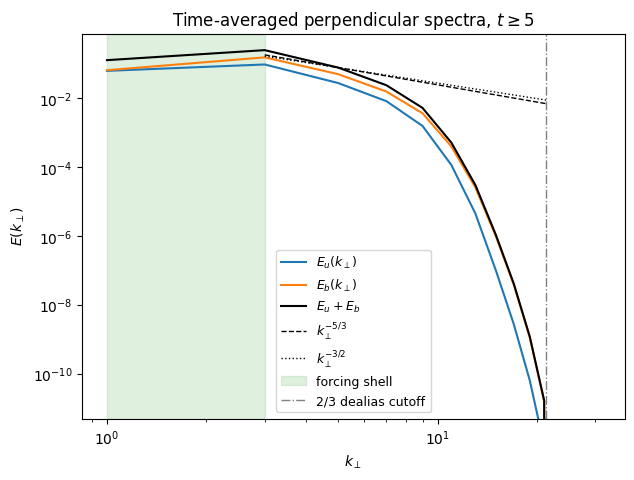

In [5]:
avg_steps = [i for i in steps if float(snaps[i].t) >= t_avg_min]
print(f"averaging over {len(avg_steps)} snapshots")

su_acc, sb_acc = 0.0, 0.0
for i in avg_steps:
    bins, su_i, sb_i = diag.perpspec(snaps[i], kgrid, params)
    su_acc, sb_acc = su_acc + su_i, sb_acc + sb_i
bins = np.asarray(bins)
su = np.asarray(su_acc) / len(avg_steps)
sb = np.asarray(sb_acc) / len(avg_steps)
Etot = su + sb
dk_perp = float(bins[1] - bins[0])

kunit = float(min(2*jnp.pi/params.Lx, 2*jnp.pi/params.Ly))
k_dealias = (2.0/3.0) * min(params.nx//2, params.ny//2) * kunit

# slope fit over the short quasi-inertial stretch between the forcing shell and the
# onset of the hyperdissipation range (see the note above -- at this resolution and
# dissipation the fit is contaminated by dissipation and comes out steep)
fitmask = (bins >= 2.5) & (bins <= 7.5)
for name, s in [('E_tot', Etot), ('E_u', su), ('E_b', sb)]:
    slope = np.polyfit(np.log(bins[fitmask]), np.log(s[fitmask]), 1)[0]
    print(f"fitted slope over k_perp in [3,7], {name}: {slope:+.2f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(bins, su, label=r'$E_u(k_\perp)$')
ax.loglog(bins, sb, label=r'$E_b(k_\perp)$')
ax.loglog(bins, Etot, 'k', lw=1.5, label=r'$E_u+E_b$')

k0 = 5.0                                   # anchor point inside the inertial range
E0 = float(np.interp(k0, bins, Etot))
kref = np.linspace(3.0, k_dealias, 50)
ax.loglog(kref, E0*(kref/k0)**(-5.0/3.0), 'k--', lw=1, label=r'$k_\perp^{-5/3}$')
ax.loglog(kref, E0*(kref/k0)**(-3.0/2.0), 'k:', lw=1, label=r'$k_\perp^{-3/2}$')

ax.axvspan(params.fshell[0]*kunit, params.fshell[1]*kunit, color='C2', alpha=0.15,
           label='forcing shell')
ax.axvline(k_dealias, color='0.5', ls='-.', lw=1, label='2/3 dealias cutoff')
ax.set_xlabel(r'$k_\perp$')
ax.set_ylabel(r'$E(k_\perp)$')
ax.set_ylim(Etot[Etot > 0].min()*0.3, Etot.max()*3)
ax.legend(fontsize=9)
ax.set_title(f'Time-averaged perpendicular spectra, $t \\geq {t_avg_min:.0f}$')
plt.show()

### 3. Elsasser spectra $E^\pm(k_\perp)$

`perpspec` just computes $\tfrac12 k_\perp^2 |f_k|^2$ shell-binned spectra of whatever
two fields the state it's handed contains. So to get Elsasser spectra we hand it a state
whose fields are $z^\pm = \phi \pm \psi$ (built with `state._replace` — never positional
`SimulationState(...)`) and read the two outputs as $E^+(k_\perp)$, $E^-(k_\perp)$.

Since $|z^+|^2 + |z^-|^2 = 2(|\hat\phi|^2 + |\hat\psi|^2)$ mode-by-mode, the spectra obey
$E_u + E_b = (E^+ + E^-)/2$ bin-by-bin — checked numerically below. With equal $\pm$
forcing powers (`forcing_power_elsasser=(0.15, 0.15)`) the turbulence is *balanced*:
$E^+ \approx E^-$ on average, so the interesting quantity is their ratio (or difference),
which makes any residual imbalance — here just statistical fluctuation — visible.
An imbalanced run (unequal injection) would show a sustained offset instead.

max |(E+ + E-)/2 - (E_u+E_b)| / (E_u+E_b) over nonzero bins: 2.10e-07


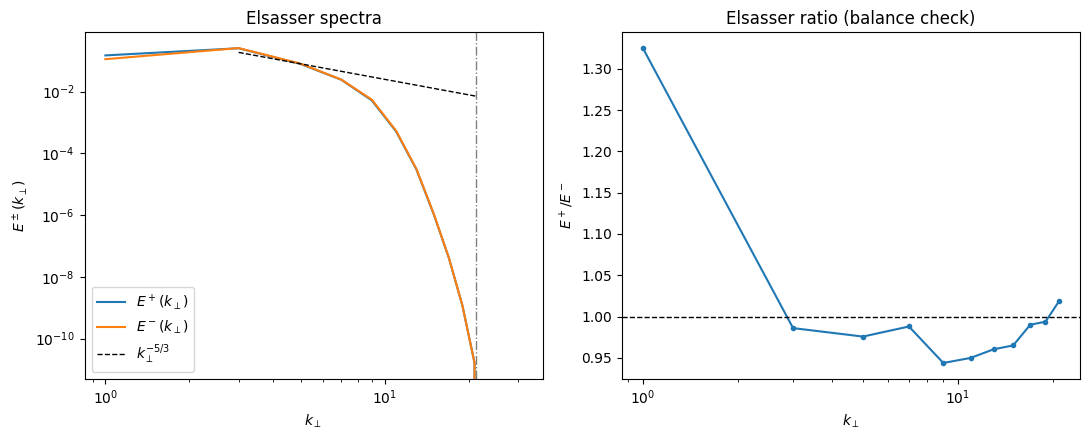

In [6]:
sp_acc, sm_acc = 0.0, 0.0
for i in avg_steps:
    f = snaps[i].fields
    zpm_state = snaps[i]._replace(fields=jnp.stack([f[0] + f[1], f[0] - f[1]]))
    _, sp_i, sm_i = diag.perpspec(zpm_state, kgrid, params)
    sp_acc, sm_acc = sp_acc + sp_i, sm_acc + sm_i
Ep = np.asarray(sp_acc) / len(avg_steps)
Em = np.asarray(sm_acc) / len(avg_steps)

# bin-by-bin identity check: E_u + E_b = (E+ + E-)/2
nz_bins = Etot > 0
maxdev = np.max(np.abs((Ep + Em)/2 - Etot)[nz_bins] / Etot[nz_bins])
print(f"max |(E+ + E-)/2 - (E_u+E_b)| / (E_u+E_b) over nonzero bins: {maxdev:.2e}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].loglog(bins, Ep, label=r'$E^+(k_\perp)$')
axes[0].loglog(bins, Em, label=r'$E^-(k_\perp)$')
axes[0].loglog(kref, E0*(kref/k0)**(-5.0/3.0), 'k--', lw=1, label=r'$k_\perp^{-5/3}$')
axes[0].axvline(k_dealias, color='0.5', ls='-.', lw=1)
axes[0].set_xlabel(r'$k_\perp$')
axes[0].set_ylabel(r'$E^\pm(k_\perp)$')
axes[0].legend()
axes[0].set_title('Elsasser spectra')

ok = (Ep > 0) & (Em > 0)
axes[1].semilogx(bins[ok], Ep[ok]/Em[ok], marker='o', ms=3)
axes[1].axhline(1.0, color='k', ls='--', lw=1)
axes[1].set_xlabel(r'$k_\perp$')
axes[1].set_ylabel(r'$E^+/E^-$')
axes[1].set_title('Elsasser ratio (balance check)')
plt.tight_layout()
plt.show()

### 4. Residual energy spectrum

$E_{res}(k_\perp) = E_u(k_\perp) - E_b(k_\perp)$. MHD turbulence tends to be *magnetically
dominated* at small scales (the "Alfvén effect" / local dynamo: nonlinear interactions
pump excess magnetic energy at each scale), so we expect $E_{res} < 0$ through the
inertial range — theory and higher-resolution simulations suggest $|E_{res}| \sim
k_\perp^{-2}$, decaying faster than the total so the fractional residual shrinks with $k$
until dissipation scales.

$E_{res}$ is signed, so a plain log-log plot can't show it: we plot $|E_{res}|$ with the
sign encoded (solid where negative — magnetically dominated — dashed where positive), and
next to it the fractional residual $E_{res}/(E_u+E_b)$, which lives in $[-1, 1]$.

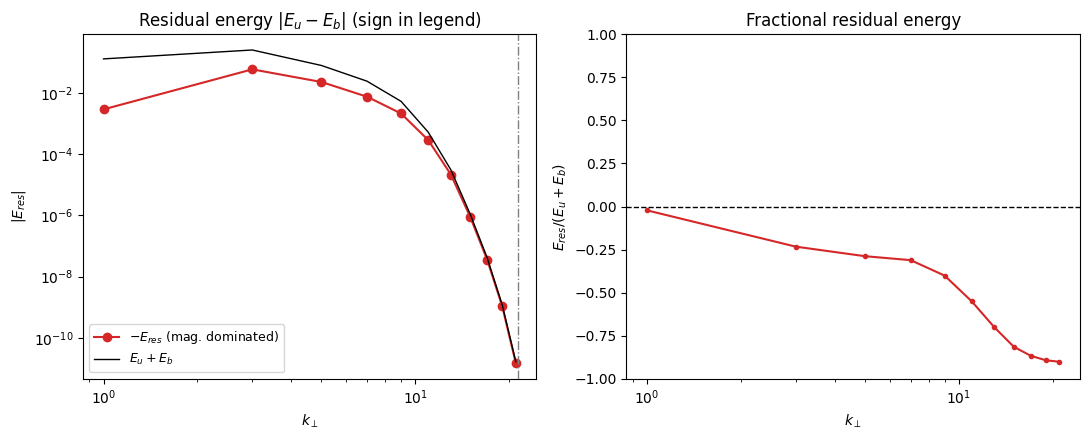

100% of nonzero bins are magnetically dominated (E_res < 0); E_res/E_tot at k=10: -0.48


In [7]:
E_res = su - sb

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
neg = (E_res < 0) & nz_bins
pos = (E_res > 0) & nz_bins
axes[0].loglog(bins[neg], -E_res[neg], 'o-', color='C3',
               label=r'$-E_{res}$ (mag. dominated)')
if pos.any():
    axes[0].loglog(bins[pos], E_res[pos], 'o--', color='C0', mfc='none',
                   label=r'$+E_{res}$ (kin. dominated)')
axes[0].loglog(bins[nz_bins], Etot[nz_bins], 'k', lw=1, label=r'$E_u+E_b$')
axes[0].axvline(k_dealias, color='0.5', ls='-.', lw=1)
axes[0].set_xlabel(r'$k_\perp$')
axes[0].set_ylabel(r'$|E_{res}|$')
axes[0].legend(fontsize=9)
axes[0].set_title(r'Residual energy $|E_u - E_b|$ (sign in legend)')

axes[1].semilogx(bins[nz_bins], E_res[nz_bins]/Etot[nz_bins], marker='o', ms=3, color='C3')
axes[1].axhline(0.0, color='k', ls='--', lw=1)
axes[1].set_xlabel(r'$k_\perp$')
axes[1].set_ylabel(r'$E_{res}/(E_u+E_b)$')
axes[1].set_ylim(-1, 1)
axes[1].set_title('Fractional residual energy')
plt.tight_layout()
plt.show()

frac_neg = neg.sum() / nz_bins.sum()
print(f"{100*frac_neg:.0f}% of nonzero bins are magnetically dominated (E_res < 0); "
      f"E_res/E_tot at k=10: {float(np.interp(10.0, bins, E_res/np.where(Etot>0,Etot,1))):+.2f}")

### 5. Parallel spectrum and spectral anisotropy

`diag.parspec` is the $k_\parallel$ (z) analog of `perpspec` — it FFTs along z, so it
needs the **whole z-domain on one rank** (`params.size == 1` is asserted inside; this is
why the generation run above is single-process).

RMHD turbulence is intrinsically anisotropic: critical balance (Goldreich–Sridhar) ties
the parallel extent of eddies to their perpendicular scale, $k_\parallel \sim
k_\perp^{2/3}$, which converts a $k_\perp^{-5/3}$ perpendicular spectrum into a much
steeper $E(k_\parallel) \sim k_\parallel^{-2}$. The overlay below shows both signatures:
the parallel spectrum falls faster than the perpendicular one from the very first bins,
and its energy-containing range is visibly narrower — the cascade extends much further in
$k_\perp$ than in $k_\parallel$, i.e. eddies are elongated along the guide field. (The
same caveat as in section 2 applies to the *fitted* value: at these parameters
dissipation steepens the measured slope past the $k_\parallel^{-2}$ reference. One
artifact to be aware of: beyond $k_\parallel \sim 10$ the parallel spectrum develops a
shallow low-amplitude tail that outlives the plunging perpendicular spectrum — the
perpendicular hyperdissipation $\propto k_\perp^6$ cannot touch high-$k_\parallel$,
low-$k_\perp$ power, which is damped only by the much gentler grid-scale z-hyperdiffusion
(`z_diss`, coefficient $\propto (dz/2)^4$).)

fitted parallel-spectrum slope over k_par in [3,7]: -3.43


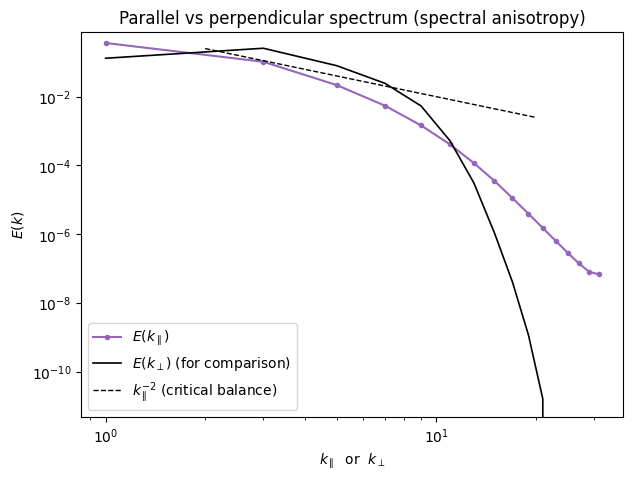

In [8]:
assert params.size == 1, "parspec needs the whole z-domain on one rank"

suz_acc, sbz_acc = 0.0, 0.0
for i in avg_steps:
    binsz, suz_i, sbz_i = diag.parspec(snaps[i], kgrid, params)
    suz_acc, sbz_acc = suz_acc + suz_i, sbz_acc + sbz_i
binsz = np.asarray(binsz)
Etotz = np.asarray(suz_acc + sbz_acc) / len(avg_steps)
dk_par = float(binsz[1] - binsz[0])

fitz = (binsz >= 2.5) & (binsz <= 7.5)
slope_par = np.polyfit(np.log(binsz[fitz]), np.log(Etotz[fitz]), 1)[0]
print(f"fitted parallel-spectrum slope over k_par in [3,7]: {slope_par:+.2f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(binsz, Etotz, 'o-', color='C4', ms=3, label=r'$E(k_\parallel)$')
ax.loglog(bins, Etot, 'k', lw=1.2, label=r'$E(k_\perp)$ (for comparison)')
kz0 = 4.0
Ez0 = float(np.interp(kz0, binsz, Etotz))
kzref = np.linspace(2.0, 20.0, 50)
ax.loglog(kzref, Ez0*(kzref/kz0)**(-2.0), 'k--', lw=1,
          label=r'$k_\parallel^{-2}$ (critical balance)')
ax.set_xlabel(r'$k_\parallel$  or  $k_\perp$')
ax.set_ylabel(r'$E(k)$')
ax.set_ylim(Etot[Etot > 0].min()*0.3, Etot.max()*3)
ax.legend()
ax.set_title('Parallel vs perpendicular spectrum (spectral anisotropy)')
plt.show()

### 6. Consistency check: spectrum integral vs total energy

The binned spectra and `diag.energy` share one normalization convention (see
`CLAUDE.md`), so integrating the time-averaged perpendicular spectrum,
$\int E(k_\perp)\,dk_\perp \approx \sum_i E_i\, dk$, must reproduce the time-averaged
total energy from section 1. Agreement should be at the few-percent level or better —
the only differences are histogram binning effects and the (negligible) power outside
the binned range. The parallel spectrum's integral is checked the same way.

In [9]:
E_spec_perp = float(np.sum(Etot) * dk_perp)
E_spec_par = float(np.sum(Etotz) * dk_par)
E_diag = float((E_kin + E_mag)[win].mean())

print(f"sum(E(k_perp)) * dk      = {E_spec_perp:.5f}")
print(f"sum(E(k_par))  * dk      = {E_spec_par:.5f}")
print(f"<E_kin + E_mag> (t >= {t_avg_min:.0f}) = {E_diag:.5f}")
print(f"perp-spectrum / energy ratio: {E_spec_perp/E_diag:.4f}")
print(f"par-spectrum  / energy ratio: {E_spec_par/E_diag:.4f}")
assert abs(E_spec_perp/E_diag - 1) < 0.05, "spectrum integral disagrees with diag.energy"
print("PASS: spectrum integral matches diag.energy to within a few percent")

sum(E(k_perp)) * dk      = 0.98202
sum(E(k_par))  * dk      = 0.98202
<E_kin + E_mag> (t >= 5) = 0.98202
perp-spectrum / energy ratio: 1.0000
par-spectrum  / energy ratio: 1.0000
PASS: spectrum integral matches diag.energy to within a few percent


### 7. Real-space context: mid-plane vorticity

A single $z$-slice of the perpendicular vorticity $\zeta = \nabla_\perp^2\phi$
($-k_\perp^2 \hat\phi$ in Fourier space) at the final snapshot — the real-space texture
behind all the spectra above. For fancier 3D renderings of the same data, see
`examples/postprocessing.ipynb`.

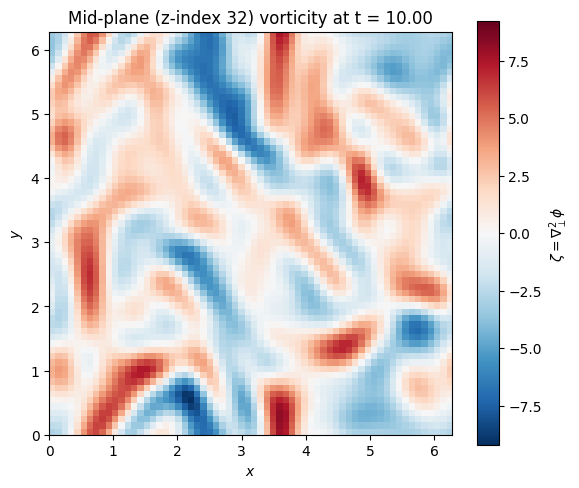

In [10]:
i_last = steps[-1]
vort = ft.irfft2(-kgrid.ksq * snaps[i_last].fields[0])   # (nz, nx, ny), real space
iz = params.nz // 2

plt.figure(figsize=(6.5, 5.5))
vmax = float(np.abs(vort[iz]).max())
plt.imshow(np.asarray(vort[iz]).T, origin='lower', cmap='RdBu_r',
           vmin=-vmax, vmax=vmax,
           extent=[0, float(params.Lx), 0, float(params.Ly)])
plt.colorbar(label=r'$\zeta = \nabla_\perp^2\phi$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.title(f'Mid-plane (z-index {iz}) vorticity at t = {float(snaps[i_last].t):.2f}')
plt.show()